# Setup

In [1]:
# importing main libs
import numpy as np
import pandas as pd

# libs for plots
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as matcolors
from matplotlib.colors import LightSource
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.tools import mpl_to_plotly

# utils
from dateutil import parser
import pprint as pp
from tqdm.notebook import tqdm

# statistical libs
from sklearn import preprocessing as prep
from scipy.stats import gaussian_kde

# models
import statsmodels.api as sm

# models (import)
from GAR.partition import retropolated_PCA
from GAR.quantfit import run_quantfit
from GAR.tsfit import run_tsfit, get_cond_quant, select_df_partition
from GAR.scenario import run_scenario, gen_shocked_PCA
from GAR.historical import run_historical
from GAR.segment import run_segment
from GAR.grid import gen_scenario_data, growth_horizons, qRegFit
from GAR.grid import cond_quant_fits, select_x_list, gen_PDF_and_CDF

# # params
# sns.set(style='whitegrid')
# sns.set(rc={'figure.figsize':(4,4)})

In [2]:
def ridgeline(data, overlap=0, fill=True, labels=None, n_points=150):
    """
    Creates a standard ridgeline plot.

    data, list of lists.
    overlap, overlap between distributions. 1 max overlap, 0 no overlap.
    fill, matplotlib color to fill the distributions.
    n_points, number of points to evaluate each distribution function.
    labels, values to place on the y axis to describe the distributions.
    """
    if overlap > 1 or overlap < 0:
        raise ValueError('overlap must be in [0 1]')
    xx = np.linspace(np.min(np.concatenate(data)),
                     np.max(np.concatenate(data)), n_points)
    curves = []
    ys = []
    for i, d in enumerate(data):
        pdf = gaussian_kde(d)
        y = i*(1.0-overlap)
        ys.append(y)
        curve = pdf(xx)
        if fill:
            plt.fill_between(xx, np.ones(n_points)*y, 
                             curve+y, zorder=len(data)-i+1, color=fill)
        plt.plot(xx, curve+y, c='k', zorder=len(data)-i+1)
    if labels:
        plt.yticks(ys, labels)

In [3]:
def ridgeline_custom(X, Y, overlap=0.7, fill_color='y', fill=True, outline=True, line_color='k',
                     y_fontsize=10, y_interval=1, dist_density=None, inline=True):
    dates = X.index.unique()[::-1]
    if (dist_density) and (dist_density!=1):
        dates = pd.DatetimeIndex([x for i, x in enumerate(dates) if (i + 1) % dist_density != 0])
    ys = []
    for index, date in enumerate(dates):
        # Setting up inputs: PDF x and y
        xx = X.loc[date]
        yy = Y.loc[date]
        y = index*(1.0-overlap)
        zorder = len(dates)-index+1
        ys.append(y)
        
        # plotting each curve
        if inline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
        if fill:
            plt.fill_between(xx, np.ones(len(xx))*y, yy+y, zorder=zorder, color=fill_color)
        if outline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
    if isinstance(dates[0], pd.Timestamp):
        plt.yticks(ys[::y_interval], dates.strftime('%Y-%b')[::y_interval])
    else:
        plt.yticks(ys[::y_interval], dates[::y_interval], fontsize=y_fontsize)

In [4]:
# Setting up parameters

# Partition groups
autoregressive = ['real_y_ms_yoy']
financial_conditions = ['consumer_AMD', 'consumer_USD', 
                        'mortgage_AMD', 'mortgage_USD', 
                        'business_AMD', 'business_USD']
policy_conditions = ['tbill', 'gbond','policy_rate']
intermediation = ['loan_to_deposit', 'spread(loan-deposit)', 'spread(loan-tbill)']
housing = ['mortgage_stock_yoy', 'rep_yoy', 'rep_deviation']
leverage = ['credit_to_gdp_gap', 'household_credit_stock_yoy', 'business_credit_stock_yoy', 
            'npl', 'assets_equity']
external_sector = ['exchange_rate', 'net_tr_yoy', 'rus_y_yoy', 'copper_yoy_lag2', 'copper_yoy']

# global parmas
dict_global_params = {'target': 'real_y_ms', 'horizon':4}
dict_groups = {
    'autoregressive': autoregressive, 
    'financial_conditions': financial_conditions, 
    'policy_conditions':policy_conditions,
    'intermediation': intermediation, 
    'housing': housing,
    'leverage': leverage,
    'external_sector':external_sector
}

# assigning a color for each group
color_mapping = {
    'autoregressive':'#1f77b4', 'financial_conditions':'#ff7f0e', 
    'policy_conditions':'#2ca02c', 'intermediation':'#d62728',
    'housing':'#9467bd', 'leverage':'#8c564b', 'external_sector':'#e377c2',
    'real_y_ms':'purple'
}
target_group = {
    'real_y_ms':['real_y_ms']
}
node_colors = {value: color_mapping[key] for key, values in (dict_groups|target_group).items() for value in values}

In [5]:
# importing data and perform pre-processing
df_partition = pd.read_excel('../data/gar_main.xlsm', 'Data')

# interpolate and forward fill missing values
for column in df_partition:
    c = df_partition[column].copy()
    if c.dtype not in [float, np.float64, np.float32]:
        continue
    f_index = c.first_valid_index()
    l_index = c.last_valid_index()
    c.loc[:l_index] = c.loc[:l_index].interpolate(method='linear')
    c.loc[f_index:] = c.loc[f_index:].fillna(method='ffill', limit=None)
    df_partition[column] = c

In [6]:
choice_columns = [
    'autoregressive', 'policy_conditions', 'intermediation',
    'housing_diff', 'external_sector_diff', 'leverage_L4',
    'external_sector_L1'
]

t_mapping = {
    **{v:v for v in choice_columns},
    'intermediation':'intermediation', 
    'intermediation_detrend':'intermediation_detrend',
    'financial_conditions':'financial_conditions',
    'financial_conditions_diff':'financial_conditions_diff',
    'housing':'housing',
    'housing_diff':'housing_diff',
    'external_sector':'external_sector',
    'external_sector_diff':'external_sector_diff',
    'external_sector_L1':'external_sector_L1',
    'leverage':'leverage',
    'leverage_L4':'leverage_L4'
}

def polytrend(series, level=1):
    index = series.reset_index().index
    z = np.polyfit(index, series, 2)
    p = np.poly1d(z)
    trend = p(index)
    return trend

# MVA
# partition[self.mapping['domestic_macro_MVA']] = partition[self.mapping['domestic_macro']].rolling(window=2).mean()
# partition.drop(columns=self.mapping['domestic_macro'], inplace=True)

class DataTransformer():
    def __init__(self):
        self.choice_columns = choice_columns
        self.mapping = t_mapping
    def transform(self, partition, depvar=None):
        
        # Lagged
        partition[self.mapping['leverage_L4']] = partition[self.mapping['leverage']].shift(4)
        partition[self.mapping['external_sector_L1']] = partition[self.mapping['external_sector']].shift(1)

        # Power
        # partition[reg_long] = partition[reg_short]**(n)

        # Diff
        partition[self.mapping['financial_conditions_diff']] = partition[self.mapping['financial_conditions']].diff(4)
        partition[self.mapping['housing_diff']] = partition[self.mapping['housing']].diff(4)
        partition[self.mapping['external_sector_diff']] = partition[self.mapping['external_sector']].diff(4)

        # Trend
        trend = polytrend(partition[self.mapping['intermediation']], 2)
        partition[self.mapping['intermediation_detrend']] = partition[self.mapping['intermediation']] - trend

         # ChangeRate
        # partition[reg_long] = partition[reg_short].pct_change(n)

        # Remove columns not in choice
        selected_columns = [value for key, value in self.mapping.items() if key in self.choice_columns]
        if type(depvar)!=type(None):
            partition = partition[['date', depvar] + selected_columns].copy()
        else:
            partition = partition[['date'] + selected_columns].copy()
        return partition

# Partitioning the input data

In [18]:
# Lets try the transformer
depvar  = dict_global_params['target'] + '_hz_' + str(dict_global_params['horizon'])
transformer = DataTransformer()
macro_data, partition_load, partition_log = retropolated_PCA(df_partition, dict_groups, **dict_global_params)
macro_data = transformer.transform(macro_data, depvar)
# display(macro_data)

# Quantile regression fit

In [7]:
# quantile regression fit step (2)
# quantlist = [0.1, 0.25, 0.5, 0.75, 0.9]
quantlist = np.arange(0.025, 0.95, 0.025).round(2)
dict_output_quantfit = run_quantfit(macro_data, quantlist=quantlist,
                                    model=sm.QuantReg, **dict_global_params)

In [8]:
qcoef = dict_output_quantfit['qcoef'].reset_index(drop=True)
cond_quant_series = dict_output_quantfit['cond_quant'].reset_index()
cond_quant_series.head()

,date,horizon,tau,realized_value,conditional_quantile_mean,conditional_quantile_mean_se,conditional_quantile_mean_ci_lower,conditional_quantile_mean_ci_upper,conditional_quantile_obs_ci_lower,conditional_quantile_obs_ci_upper
0,2004-03-31,4,0.02,10.500432,4.453887,NaN,NaN,NaN,NaN,NaN
1,2004-06-30,4,0.02,11.382368,4.387247,NaN,NaN,NaN,NaN,NaN
2,2004-09-30,4,0.02,11.441260,6.381370,NaN,NaN,NaN,NaN,NaN
3,2004-12-31,4,0.02,13.825052,13.239902,NaN,NaN,NaN,NaN,NaN
4,2005-03-31,4,0.02,14.508530,14.508530,NaN,NaN,NaN,NaN,NaN


# T-skew fit

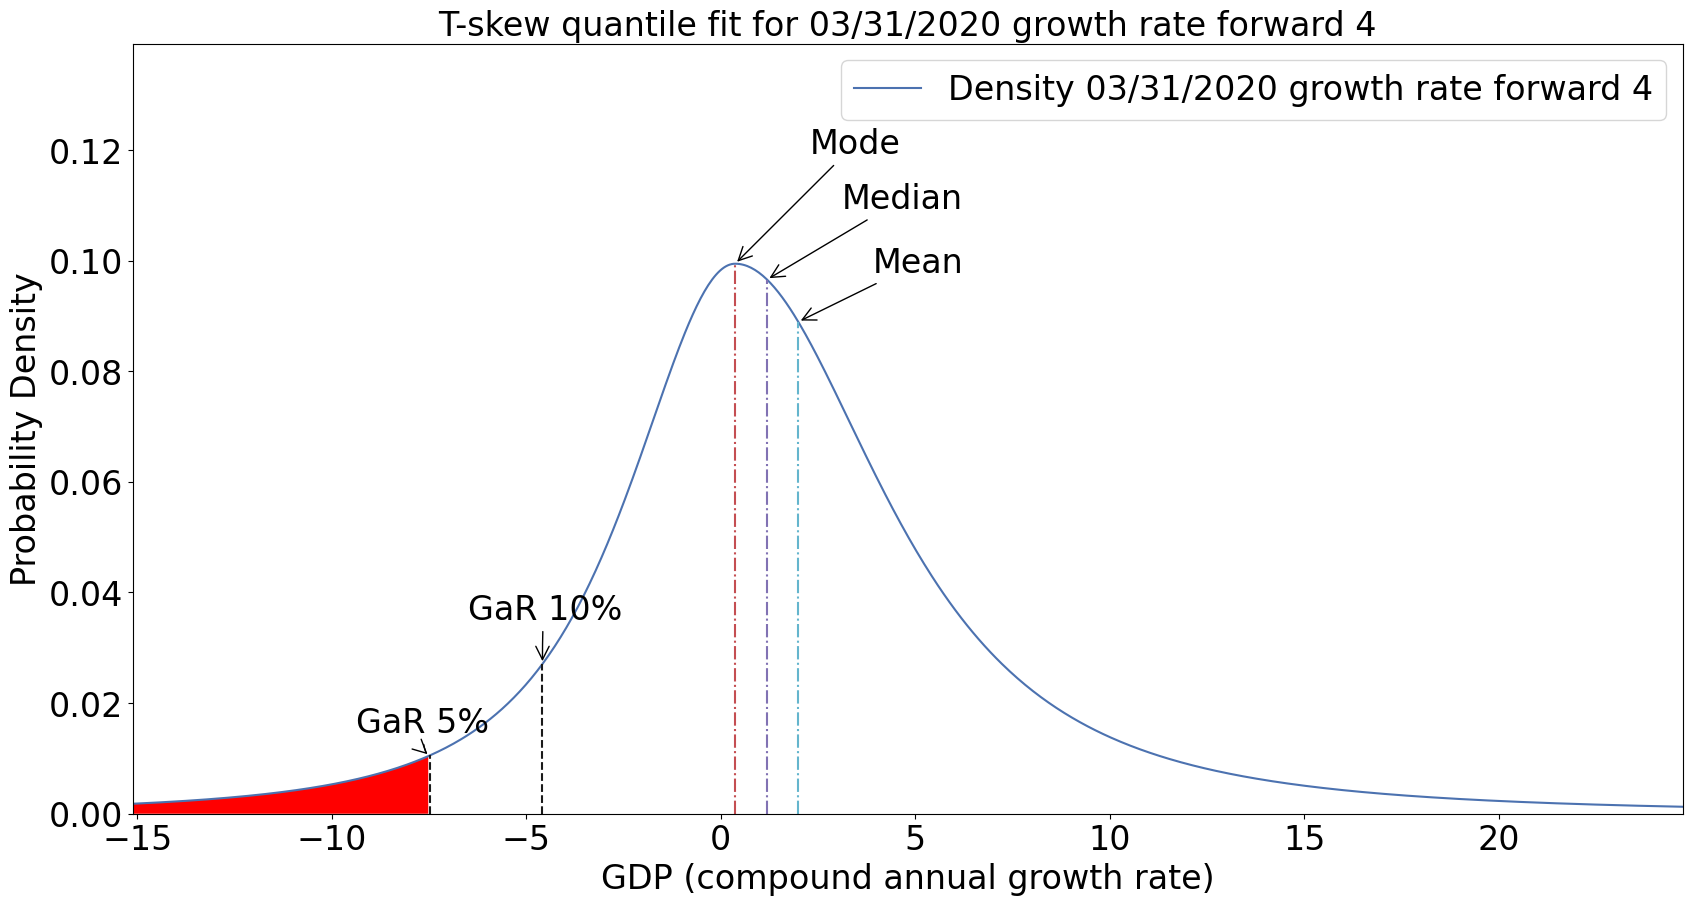

In [38]:
# theme setup
sns.reset_defaults()

# tsfit input data:
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':None},
    'qsmooth': 'None',
    'qsmooth_period': None,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': True,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# tsfit step (3)
dict_output_tsfit = run_tsfit(latest_date, fit_params, macro_data, qcoef, **dict_global_params)
dfpdf = dict_output_tsfit['dfpdf']
fitted_params = dict(dict_output_tsfit['result'])
dict_output_tsfit['fig']

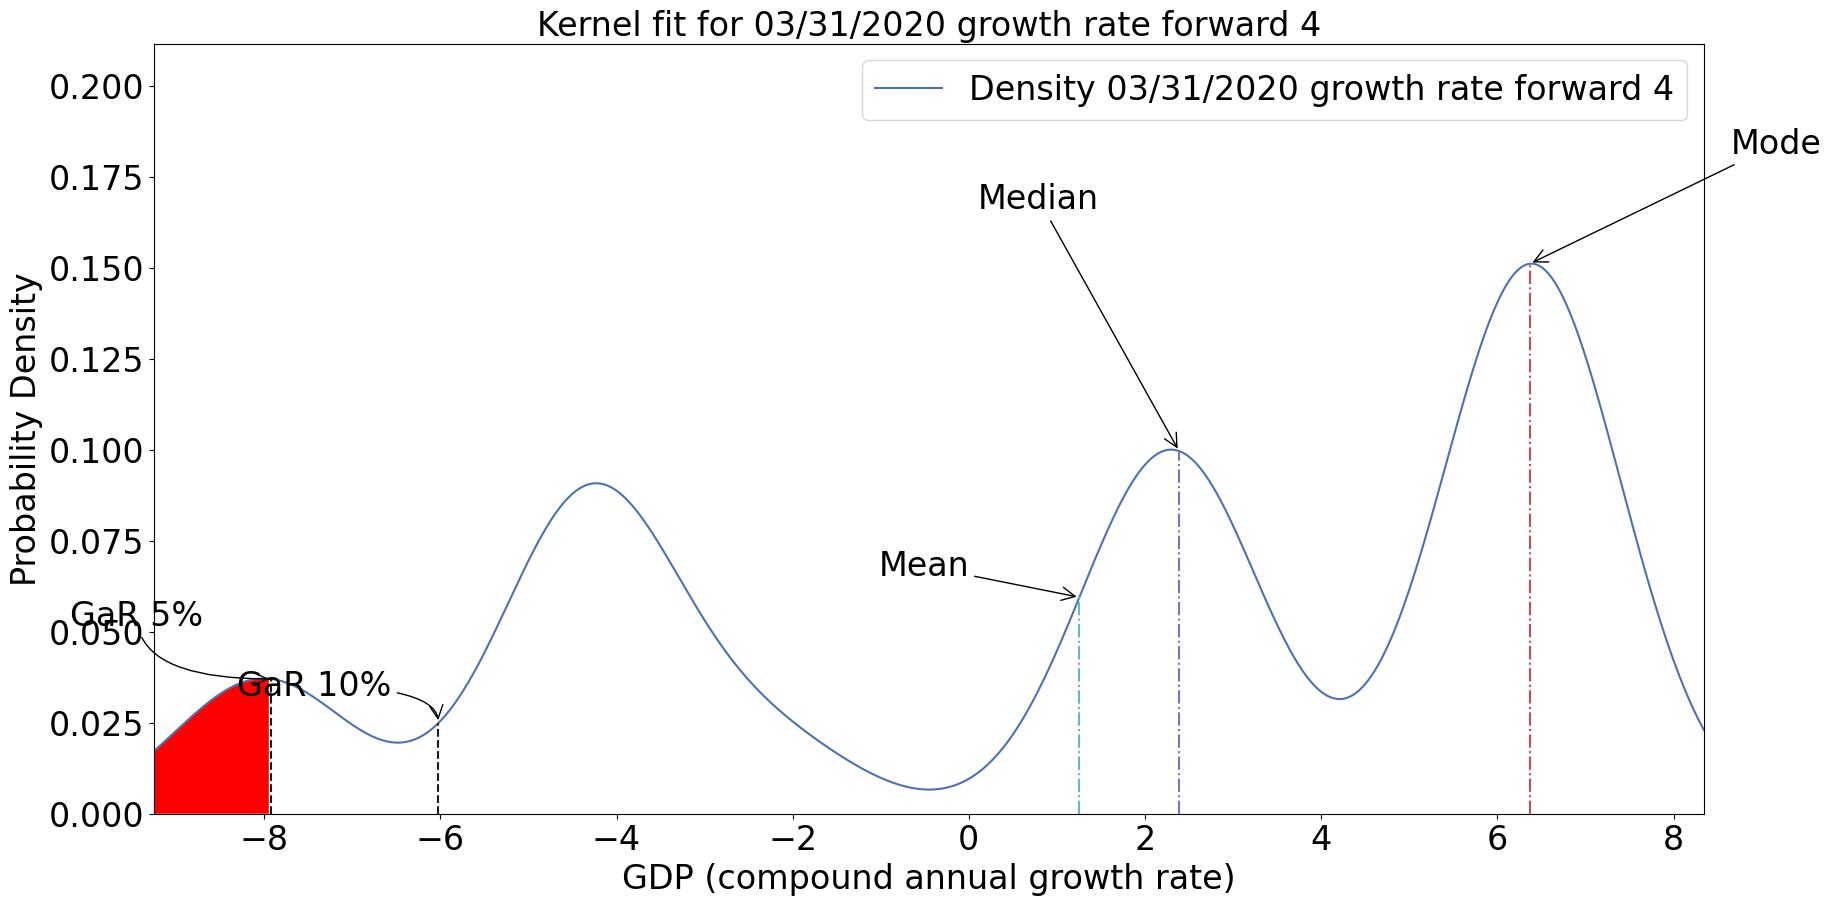

In [41]:
# tsfit input data:
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':1},
    'qsmooth': 'None',
    'qsmooth_period': None,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': True,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# tsfit step (3)
dict_output_tsfit = run_tsfit(latest_date, fit_params, macro_data, qcoef, **dict_global_params)
dfpdf = dict_output_tsfit['dfpdf']
fitted_params = dict(dict_output_tsfit['result'])
dict_output_tsfit['fig']

# Counterfactual Scenarios Analysis

In [11]:
# theme setup
sns.reset_defaults()

# shocktype: 'By +/- STD' or 'By +/- percentage' 
shockvars = {
    'tbill': {
        'shocktype': 'By +/- STD',
        'shockvalue': 10
    }
}

# generating shocked series
transformer = DataTransformer()
df_shockedvar, df_shockedgrp = gen_shocked_PCA(shockvars, dict_groups, df_partition, 
                                               transformer, **dict_global_params)
df_shockedgrp.columns = df_shockedgrp.columns.str.replace('_shocked', '')

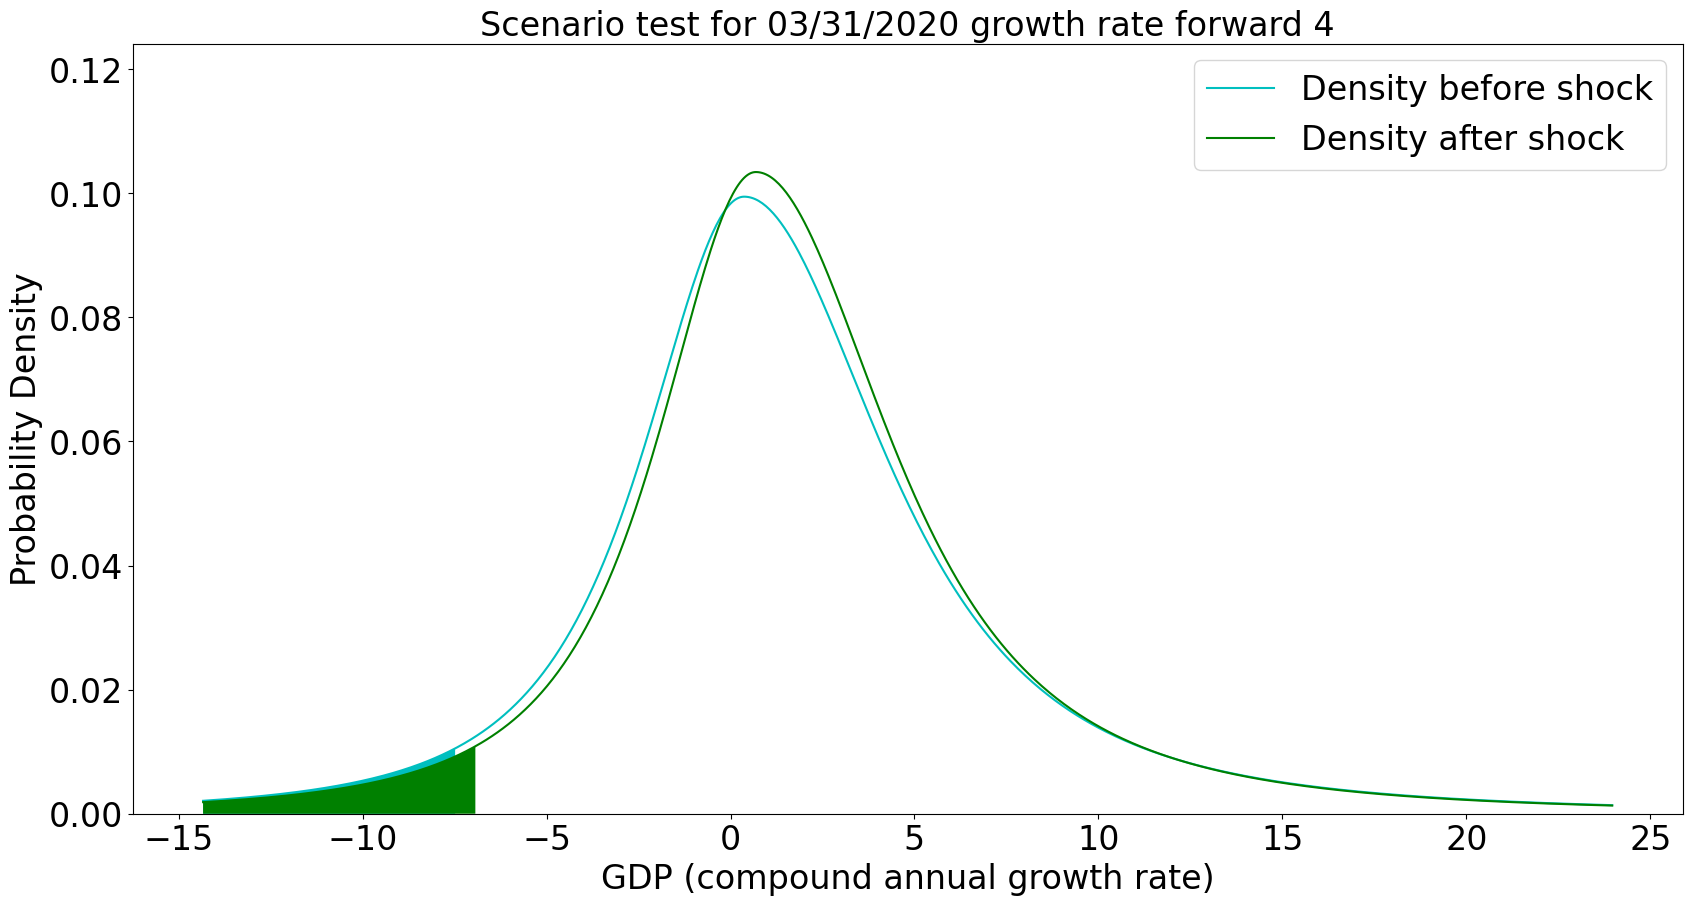

In [12]:
# scenario input data:
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':None},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

fit_params_shocked = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':None},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

# calculating conditional quantiles
cond_quant = get_cond_quant(latest_date, macro_data, qcoef, **dict_global_params)
cond_quant_shocked = get_cond_quant(latest_date, df_shockedgrp, qcoef, **dict_global_params)

# run the distributional fit and plot the data
dict_output_scenario = run_scenario(latest_date, cond_quant, cond_quant_shocked, 
                                    fit_params, fit_params_shocked, **dict_global_params)
dict_output_scenario['fig'].savefig('../Results/Scenario_test.png', bbox_inches='tight', dpi=300)
dict_output_scenario['fig']

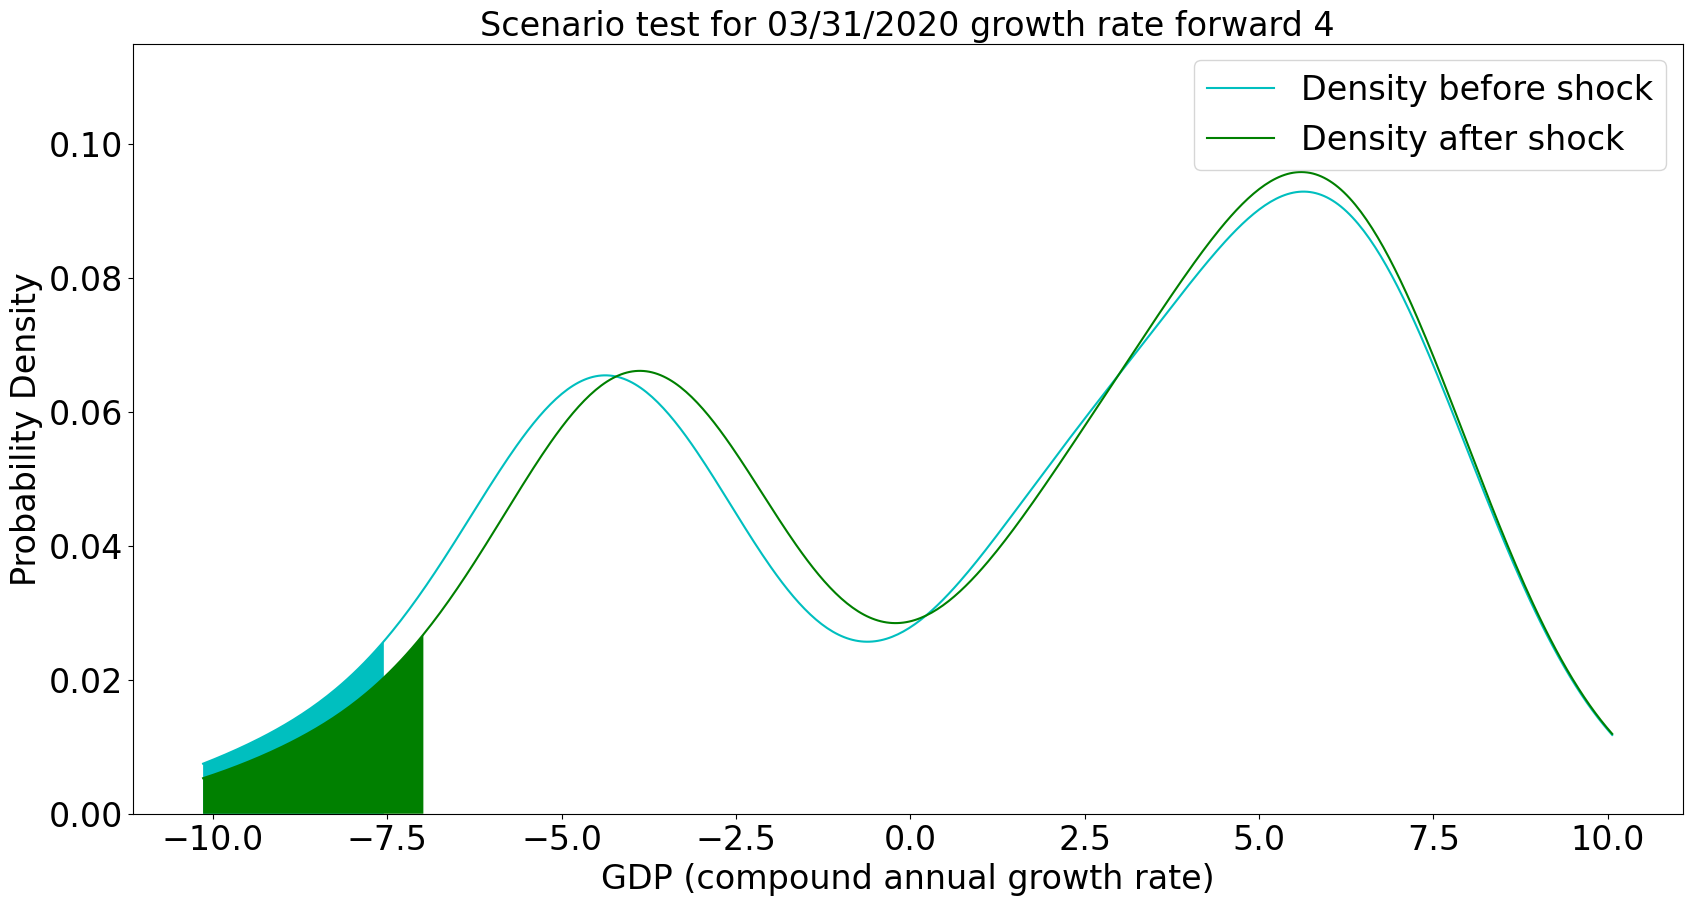

In [13]:
# scenario input data:
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':2},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

fit_params_shocked = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':2},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

# calculating conditional quantiles
cond_quant = get_cond_quant(latest_date, macro_data, qcoef, **dict_global_params)
cond_quant_shocked = get_cond_quant(latest_date, df_shockedgrp, qcoef, **dict_global_params)

# run the distributional fit and plot the data
dict_output_scenario = run_scenario(latest_date, cond_quant, cond_quant_shocked, 
                                    fit_params, fit_params_shocked, **dict_global_params)
dict_output_scenario['fig'].savefig('../Results/Scenario_kernel_test.png', bbox_inches='tight', dpi=300)
dict_output_scenario['fig']

In [14]:
display(dict_output_scenario['res'])

,Date of input,Horizon forward,Conditional mode,Conditional median,Conditional mean,GaR5%,GaR10%,kernel_weights,kernel_bandwidth,kernel_model,scenario
0,2020-03-31,4,5.650726,2.597517,1.310865,-7.493619,-6.120105,"[0.045864516898429845, 0.0, 0.0, 0.0, 5.366800...",2,<GAR.kernel.Weighted_kernel object at 0x7fabe8...,before shock
1,2020-03-31,4,5.610238,2.784766,1.512503,-6.956078,-5.611262,"[0.04402483168524758, 7.453889935837843e-19, 0...",2,<GAR.kernel.Weighted_kernel object at 0x7fabe8...,after shock


# Historical dist

In [68]:
# theme setup
sns.reset_defaults()
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
hist_fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':None},
    'qsmooth': 'Mean',
    'qsmooth_period': 4,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_historical = {
    'start_date': parser.parse('2003-03-31'),
    'end_date': parser.parse('2022-03-31'),
    'time_inc': 1,
    'fit_params': hist_fit_params,
    **dict_global_params
}
dict_output_historical_tskew = run_historical(dict_input_historical, macro_data, qcoef)

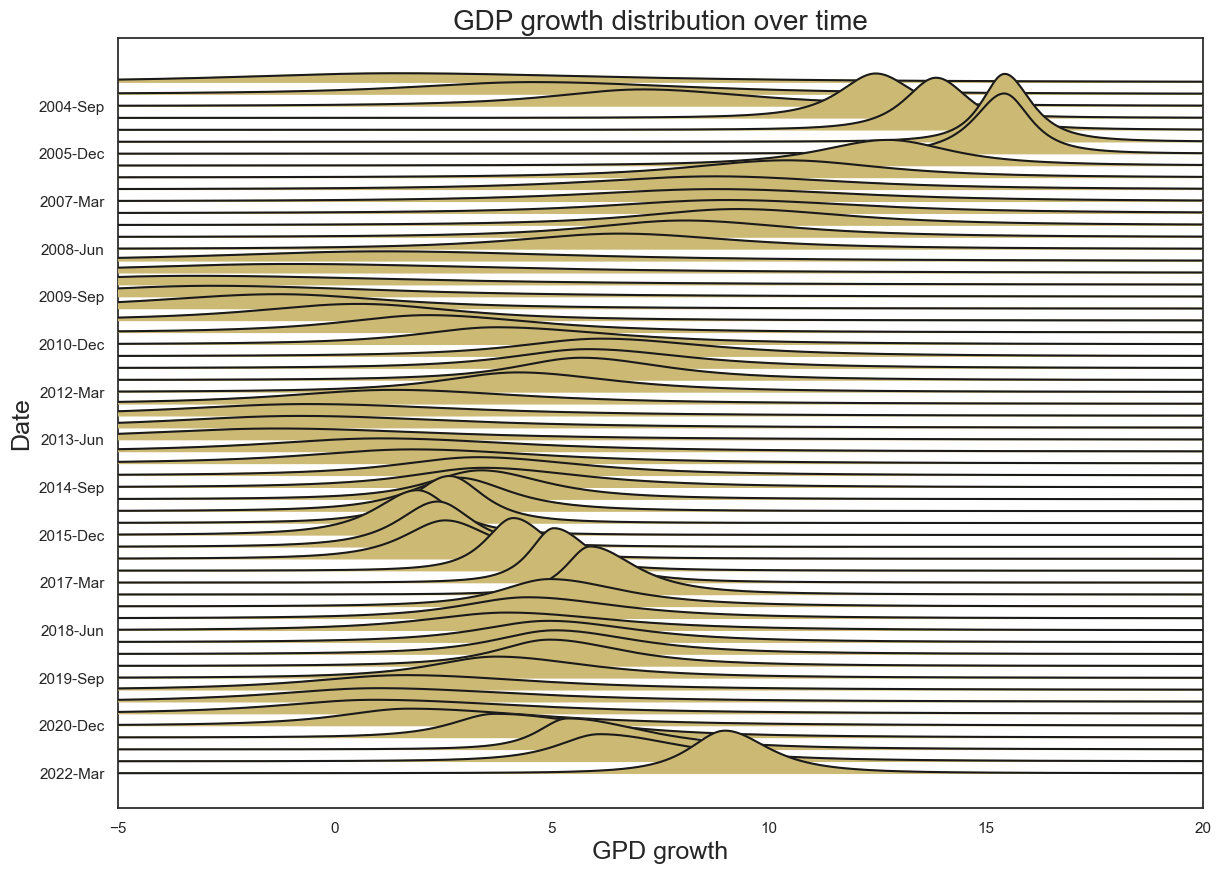

In [69]:
# data setup
hist_sim_tskew_data = dict_output_historical_tskew['data']
df_PDF_skew = pd.concat(hist_sim_tskew_data['dfpdf'].values, keys=hist_sim_tskew_data['dfpdf'].index).reset_index(level=1, drop=True)
df_PDF_skew = df_PDF_skew.reset_index().rename(columns={'index':'date'})
plot_data = df_PDF_skew.set_index('date').copy()

# plotting
plt.figure(figsize=(14,10))        
ridgeline_custom(plot_data['Tskew_PDF_x'], plot_data['Tskew_PDF_y'], overlap=0.9, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4, 
                 dist_density=5, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.xlim(-5, 20)
plt.show()

In [74]:
# mode: Free vs Fixed
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
hist_fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':3},
    'qsmooth': 'Mean',
    'qsmooth_period': 4,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_historical = {
    'start_date': parser.parse('2003-03-31'),
    'end_date': parser.parse('2022-03-31'),
    'time_inc': 1,
    'fit_params': hist_fit_params,
    **dict_global_params
}
dict_output_historical_kernel = run_historical(dict_input_historical, macro_data, qcoef)

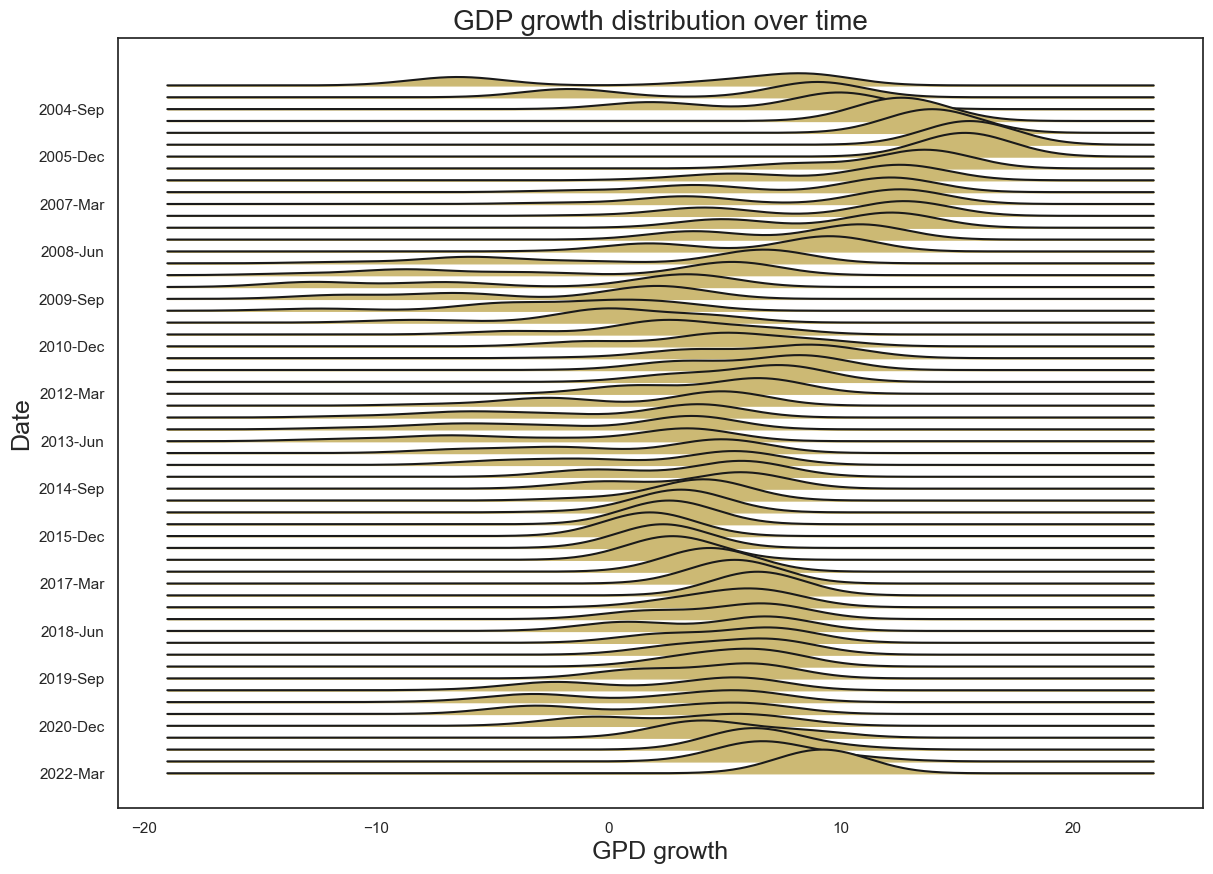

In [75]:
# data setup
hist_sim_kernel_data = dict_output_historical_kernel['data']
df_PDF_kernel = pd.concat(hist_sim_kernel_data['dfpdf'].values, keys=hist_sim_kernel_data['dfpdf'].index).reset_index(level=1, drop=True)
df_PDF_kernel = df_PDF_kernel.reset_index().rename(columns={'index':'date'})
plot_data = df_PDF_kernel.set_index('date').copy()

# plotting
plt.figure(figsize=(14,10))        
ridgeline_custom(plot_data['Kernel_PDF_x'], plot_data['Kernel_PDF_y'], overlap=0.9, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4, 
                 dist_density=5, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.show()

# Multiple Horizon Projections

In [53]:
latest_date = parser.parse('2020-03-31')
quantlist = np.arange(0.025, 0.95, 0.025).round(2)
transformer = DataTransformer()

# qsmooth_period: int or "auto" (in case of auto its equal to the horizon)
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
segment_fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'bandwidth':2},
    'qsmooth': "None",
    'qsmooth_period': None,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_segment = {
    'horizonlist': [4, 8, 12, 16],
    'method_growth':'cpd',
    'retropolate':'Yes',
    'partition_groups': dict_groups,
    'transformer':transformer,
    'quantlist': quantlist,
    'fitdate': latest_date,
    'fit_params': segment_fit_params,
    'fitconstrainlist': ['Free']*4,
    'fitconstrainvalues': [None]*4,
    **dict_global_params
}
dict_output_segment = run_segment(dict_input_segment, df_partition, model=sm.QuantReg)

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.



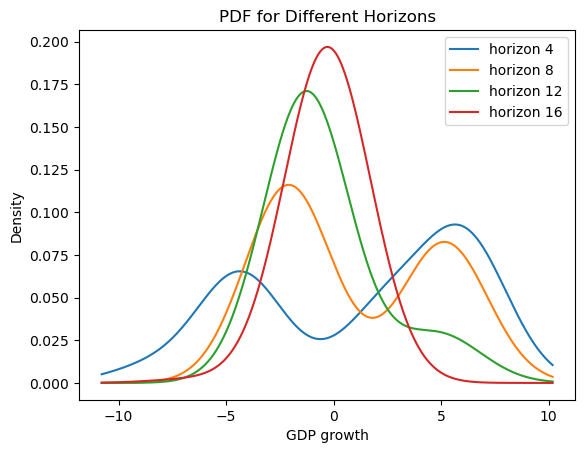

In [54]:
# data setup
def expand_dfpdf(row):
    dfpdf = row['dfpdf']
    dfpdf['horizon'] = row['horizon']
    return dfpdf
dfpdf_segment = pd.concat(list(dict_output_segment.apply(expand_dfpdf, axis=1)))

# Plotting Kernel_PDF_x and Kernel_PDF_y for each horizon
for horizon in dfpdf_segment['horizon'].unique():
    subset = dfpdf_segment[dfpdf_segment['horizon'] == horizon]
    x_values = subset['Kernel_PDF_x'].values
    y_values = subset['Kernel_PDF_y'].values
    plt.plot(x_values, y_values, label=f'horizon {horizon}')

# Add labels and title to the plot
plt.xlabel('GDP growth')
plt.ylabel('Density')
plt.title('PDF for Different Horizons')
plt.legend()

# Display the plot
plt.show()

# Grid Projection

In [7]:
def gen_scenario_horizons(y_horizons, scenarios, quantlist, horizonlist, 
                          dates, fit_params, methods, qReg_model):
    res_fits = []
    qcoeff_horizons = []
    for horizon, y in tqdm(list(zip(horizonlist, y_horizons))):
        for scenario_name, scenario_data in scenarios.items():
            # running quantile reg (Q-fit) 16x2x37 (horizon-scenario-quantiles)
            qcoeff, cond_quant = qRegFit(y, scenario_name, scenario_data, 
                                         quantlist, horizon, qReg_model)
            # Subset selection 16x2x37x77 (horizon-scenario-quantiles-dates)
            # distributional model fit for conditional quantiles  16x2x77x3 (horizon-scenario-dates-methods)
            cond_quant_method_fits = cond_quant_fits(dates, scenario_data, 
                                                     qcoeff, fit_params, methods)
            res_fits.append(cond_quant_method_fits)
            qcoeff_horizons.append(qcoeff)
            
    # combine horizon-scenario-qfits into qfits
    res_fits = [res_fit for method_fits in res_fits for res_fit in method_fits]
    # extract the fits for all horizons and scenarios and select fixed x values
    model_fits = [res_fit['model_fit'] for res_fit in res_fits]
    methods = [res_fit['method'] for res_fit in res_fits]
    x = select_x_list(model_fits, methods)
    
    # get dfpdf using a fixed set for x
    for res_fit in tqdm(res_fits):
        model_fit = res_fit['model_fit']
        loc = res_fit['modx']
        method = res_fit['method']
        res_fit['dfpdf'] = gen_PDF_and_CDF(model_fit, method, x, loc)
    res_fits = pd.DataFrame(res_fits)
    qcoeff_horizons = pd.concat(qcoeff_horizons)
    return res_fits, qcoeff_horizons

In [8]:
# Grid inputs
target =  'real_y_ms'
methods = ['T-skew', "Kernel-based"]
quantlist = np.arange(0.025, 1, 0.025).round(2)
horizonlist = np.arange(1, 17, 1)
y_horizons = growth_horizons(target, horizonlist, df_partition, method_growth='cpd')
transformer = DataTransformer()
qReg_model = sm.QuantReg
fit_params = {
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':2},
    'qsmooth': "None",
    'qsmooth_period': 2,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

# generating scenario data, shocktype: 'By +/- STD' or 'By +/- percentage' 
shockvar_dict = {'tbill shock':{'tbill': {'shocktype': 'By +/- STD', 'shockvalue': 10}}}
scenarios = gen_scenario_data(shockvar_dict, dict_groups, df_partition)
scenarios = {scenario: transformer.transform(data).set_index('date') for scenario, data in scenarios.items()}

# defining all valid dates
dates = scenarios['baseline'].dropna().index

# fit a distribution for quantiles at every horizon, scenario, date with all methods
cond_quants, qcoeffs = gen_scenario_horizons(y_horizons, scenarios, quantlist, horizonlist, 
                                             dates, fit_params, methods, qReg_model)

# # save results into pickle files
# cond_quants.to_pickle("../data/cond_quants.pkl")
# qcoeffs.to_pickle("../data/qcoeffs.pkl")

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/4672 [00:00<?, ?it/s]

# Results

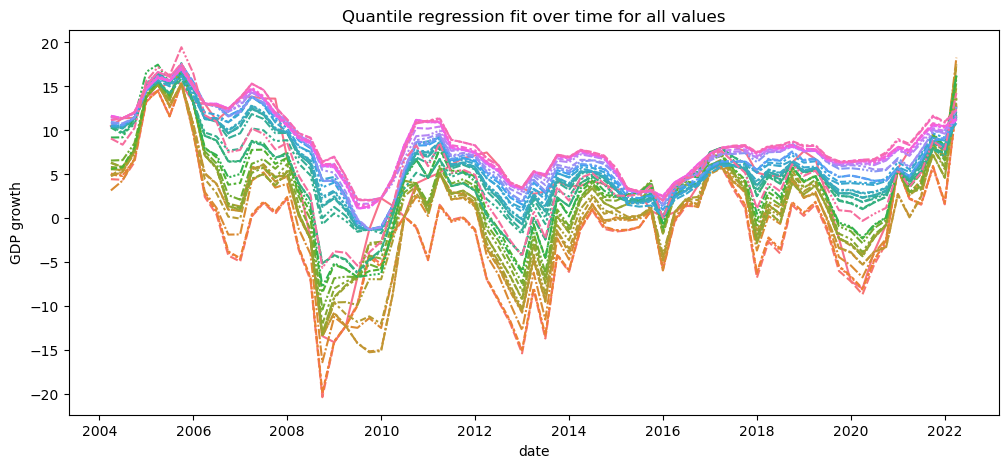

In [95]:
sns.reset_defaults()
qfit_series = cond_quant_series.pivot_table(values='conditional_quantile_mean', index='date', columns='tau')
qfit_series = pd.merge(qfit_series, macro_data[['date','real_y_ms_hz_4']], how='left', on='date')
qfit_series = qfit_series[[qfit_series.columns[-1]] + list(qfit_series.columns[:-1])]
qfit_series = qfit_series.set_index('date')
# palette = {
#     0.1: 'red',
#     0.25: 'green',
#     0.5: 'orange',
#     0.75: 'purple',
#     0.9: 'brown',
#     'mean': 'gray',
#     'real_y_ms_hz_4': 'black'
# }
fig, ax = plt.subplots(figsize=(12, 5))
# sns.lineplot(data=qfit_series, palette=palette, ax=ax)
g = sns.lineplot(data=qfit_series, ax=ax)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth')
# plt.savefig('../Results/QRfit_over_time.png', bbox_inches='tight', dpi=300)
plt.legend([], [], frameon=False)
plt.show()

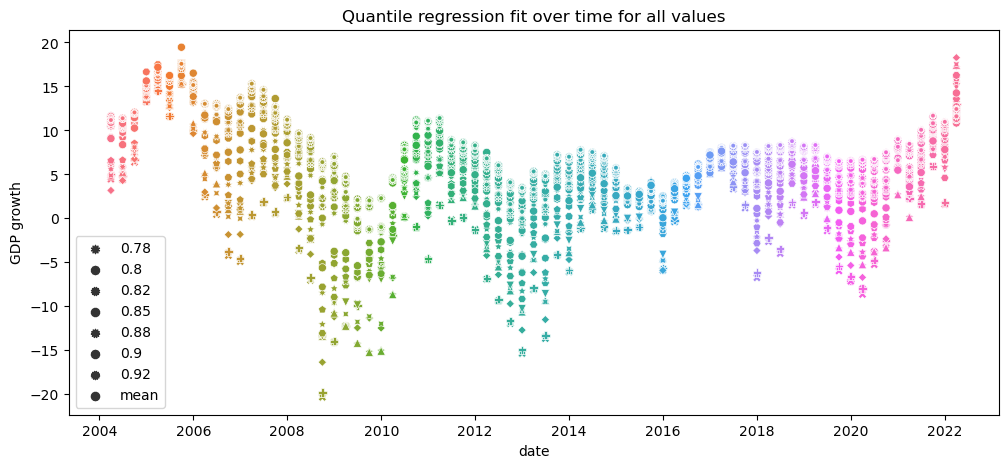

In [96]:
qdist = qfit_series.reset_index().melt(id_vars='date', value_vars=['real_y_ms_hz_4',*quantlist, 'mean'])
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(data=qdist, x='date', y='value', hue='date', style='variable', legend=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-8:], labels[-8:], frameon=True)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth') 
# plt.savefig('../Results/QRfit_points_over_time.png', bbox_inches='tight', dpi=300)
plt.show()

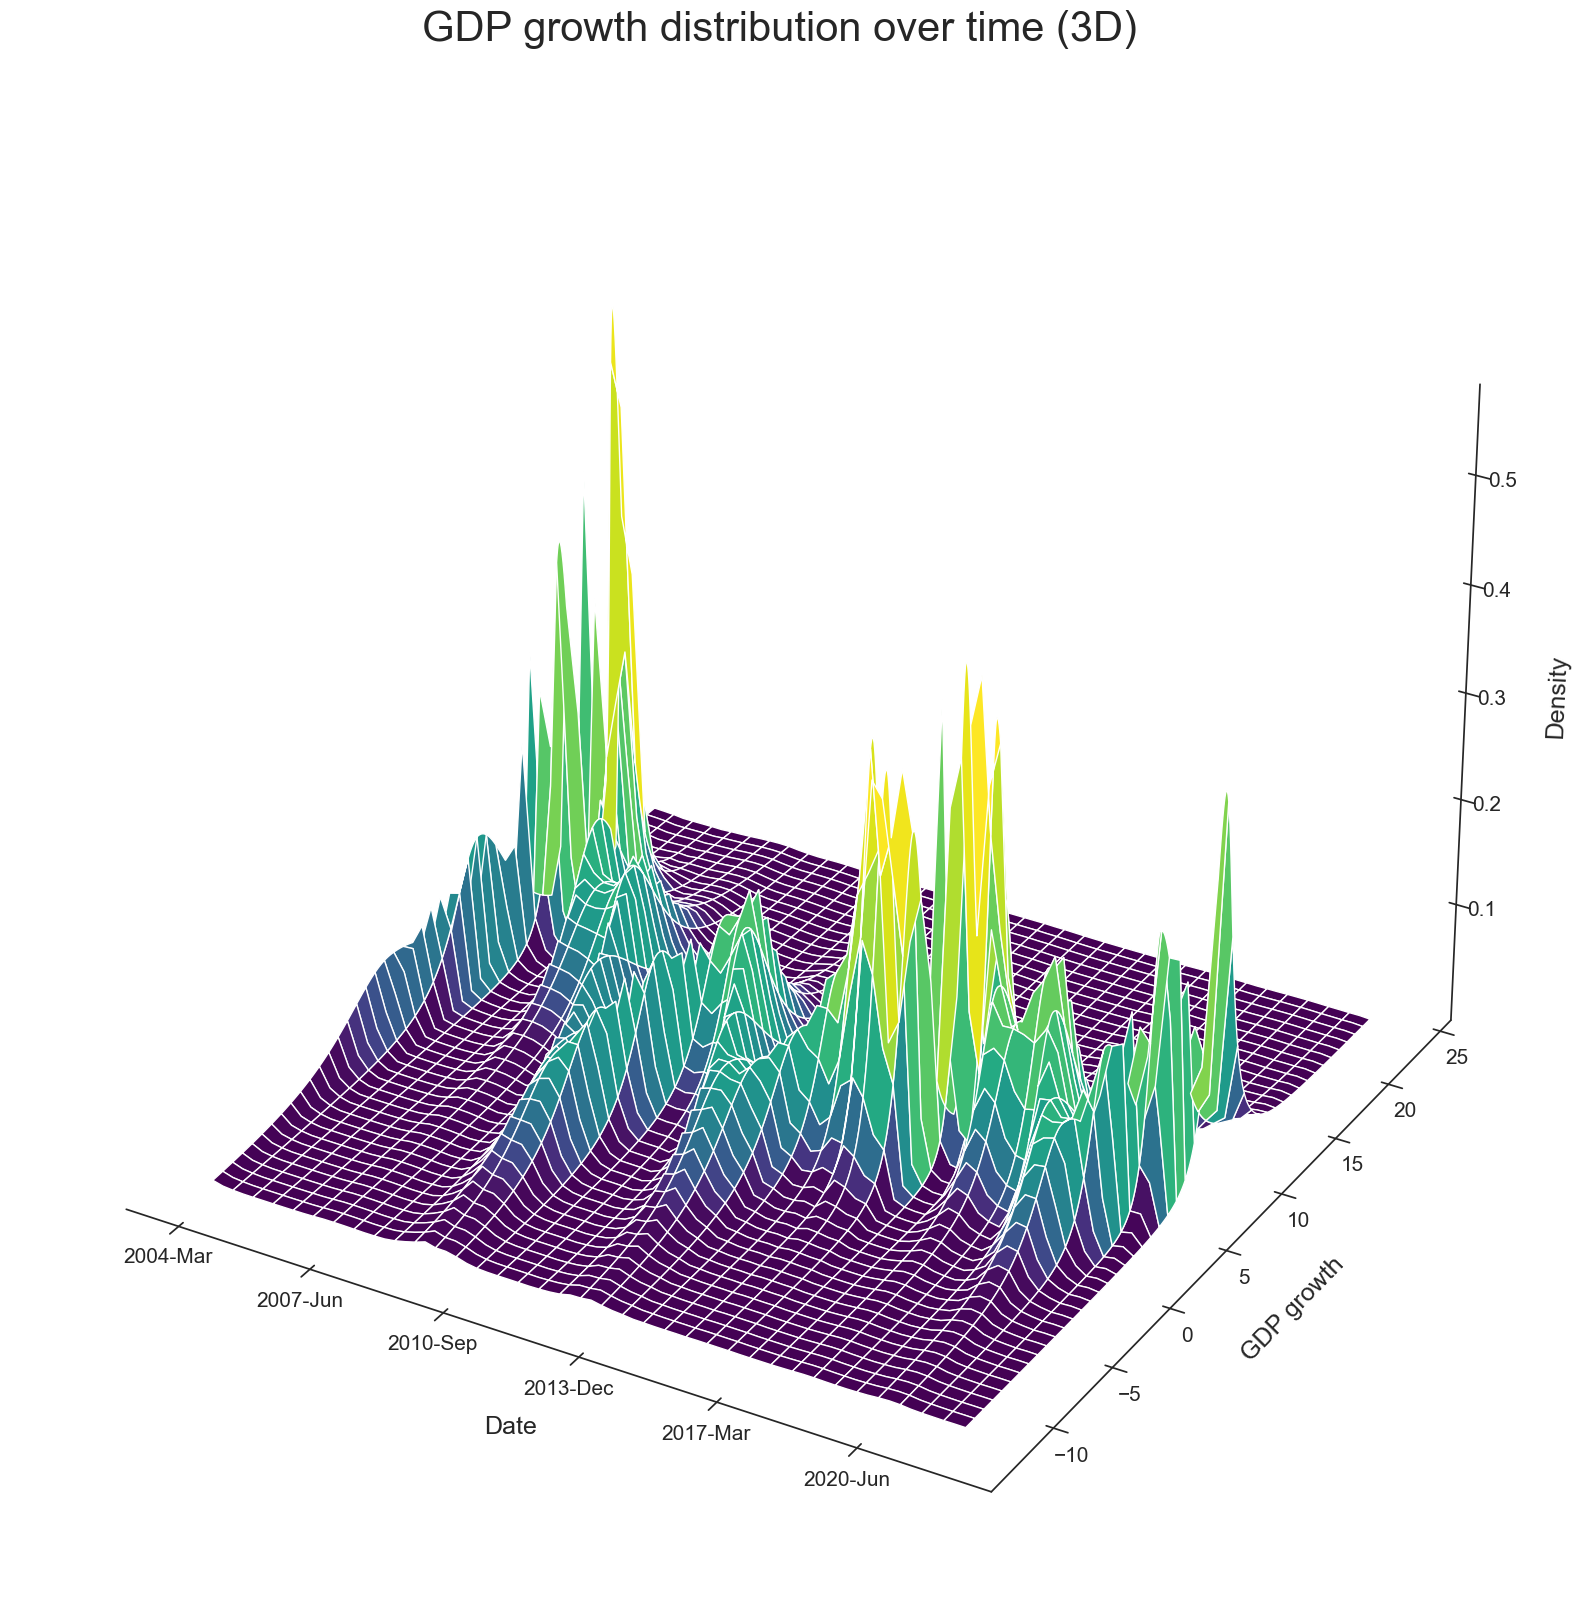

In [97]:
# custom outline
sns.set_theme(style="white", palette='viridis')

# Data preparation
method = 'Tskew'
gdp_growth = df_PDF_skew.groupby('date')[method+'_PDF_x'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = df_PDF_skew.groupby('date')[method+'_PDF_y'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis, 
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'))
ax.set_xlabel('Date', fontsize=18, labelpad=20)
ax.set_ylabel('GDP growth', fontsize=18, labelpad=20)
ax.set_zlabel('Density', fontsize=18, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('GDP growth distribution over time (3D)', fontsize=30)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
# plt.savefig('../Results/GDP_growth_dist_3D.png', bbox_inches='tight', dpi=300)
plt.show()

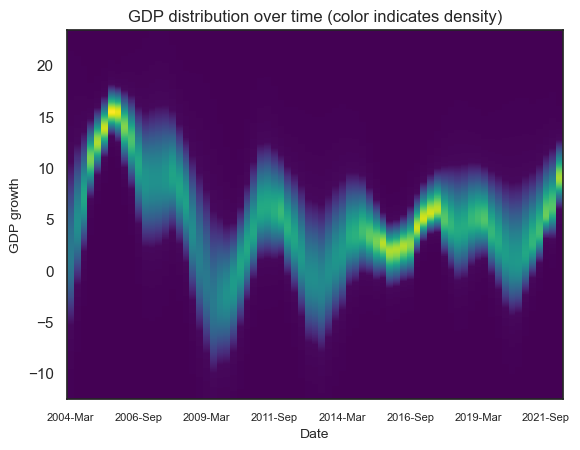

In [98]:
sns.reset_defaults()
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

fig, ax = plt.subplots(1, 1)
ax.pcolormesh(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis,
              norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::10])
ax.set_xticklabels(dates[0::10].strftime('%Y-%b'), fontsize=8)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('GDP growth', fontsize=10)
plt.title('GDP distribution over time (color indicates density)')
# plt.savefig('../Results/GDP_growth_dist_2D.png', bbox_inches='tight', dpi=300)
plt.show()

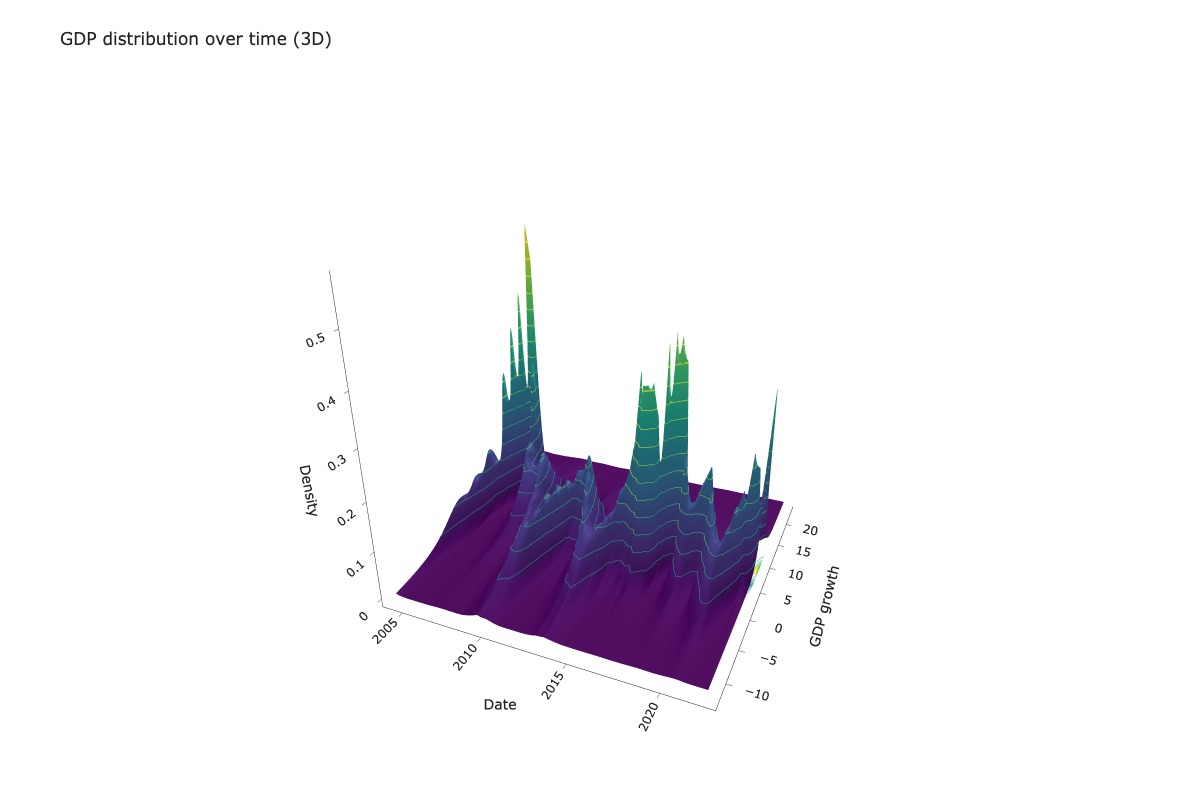

In [101]:
# scaler = prep.Normalizer('l1')
# surf_color = scaler.fit_transform(gdp_density.values.reshape((1, -1))).reshape(gdp_density.values.shape)
surf_color = gdp_density

contours = {
    "z": {"show": True, "start": 0, "end": 1, 
          "size": 1/30, "width": 16, "color": 'white',
          'usecolormap':True, 'highlightcolor':"limegreen",
          'project_z':True
         }
}
surf = go.Surface(x=dates_grid, y=gdp_growth, z=gdp_density,
                  surfacecolor=surf_color, colorscale='Viridis',
                  connectgaps=True, opacity=1, showscale=False,
                  contours=contours)
fig = go.Figure(data=[surf])

fig.update_layout(
    template='simple_white',
    title='GDP distribution over time (3D)',
    autosize=False,
    scene=dict(
        camera_eye=dict(x=0.8, y=-1.9, z=1),
        xaxis_title='Date',
        yaxis_title='GDP growth',
        zaxis_title='Density'
    ),
    width=1200,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
)
# fig.write_html('../Results/GDP_dist_interactive.html')
fig.show(renderer='png', width=1200, height=800)

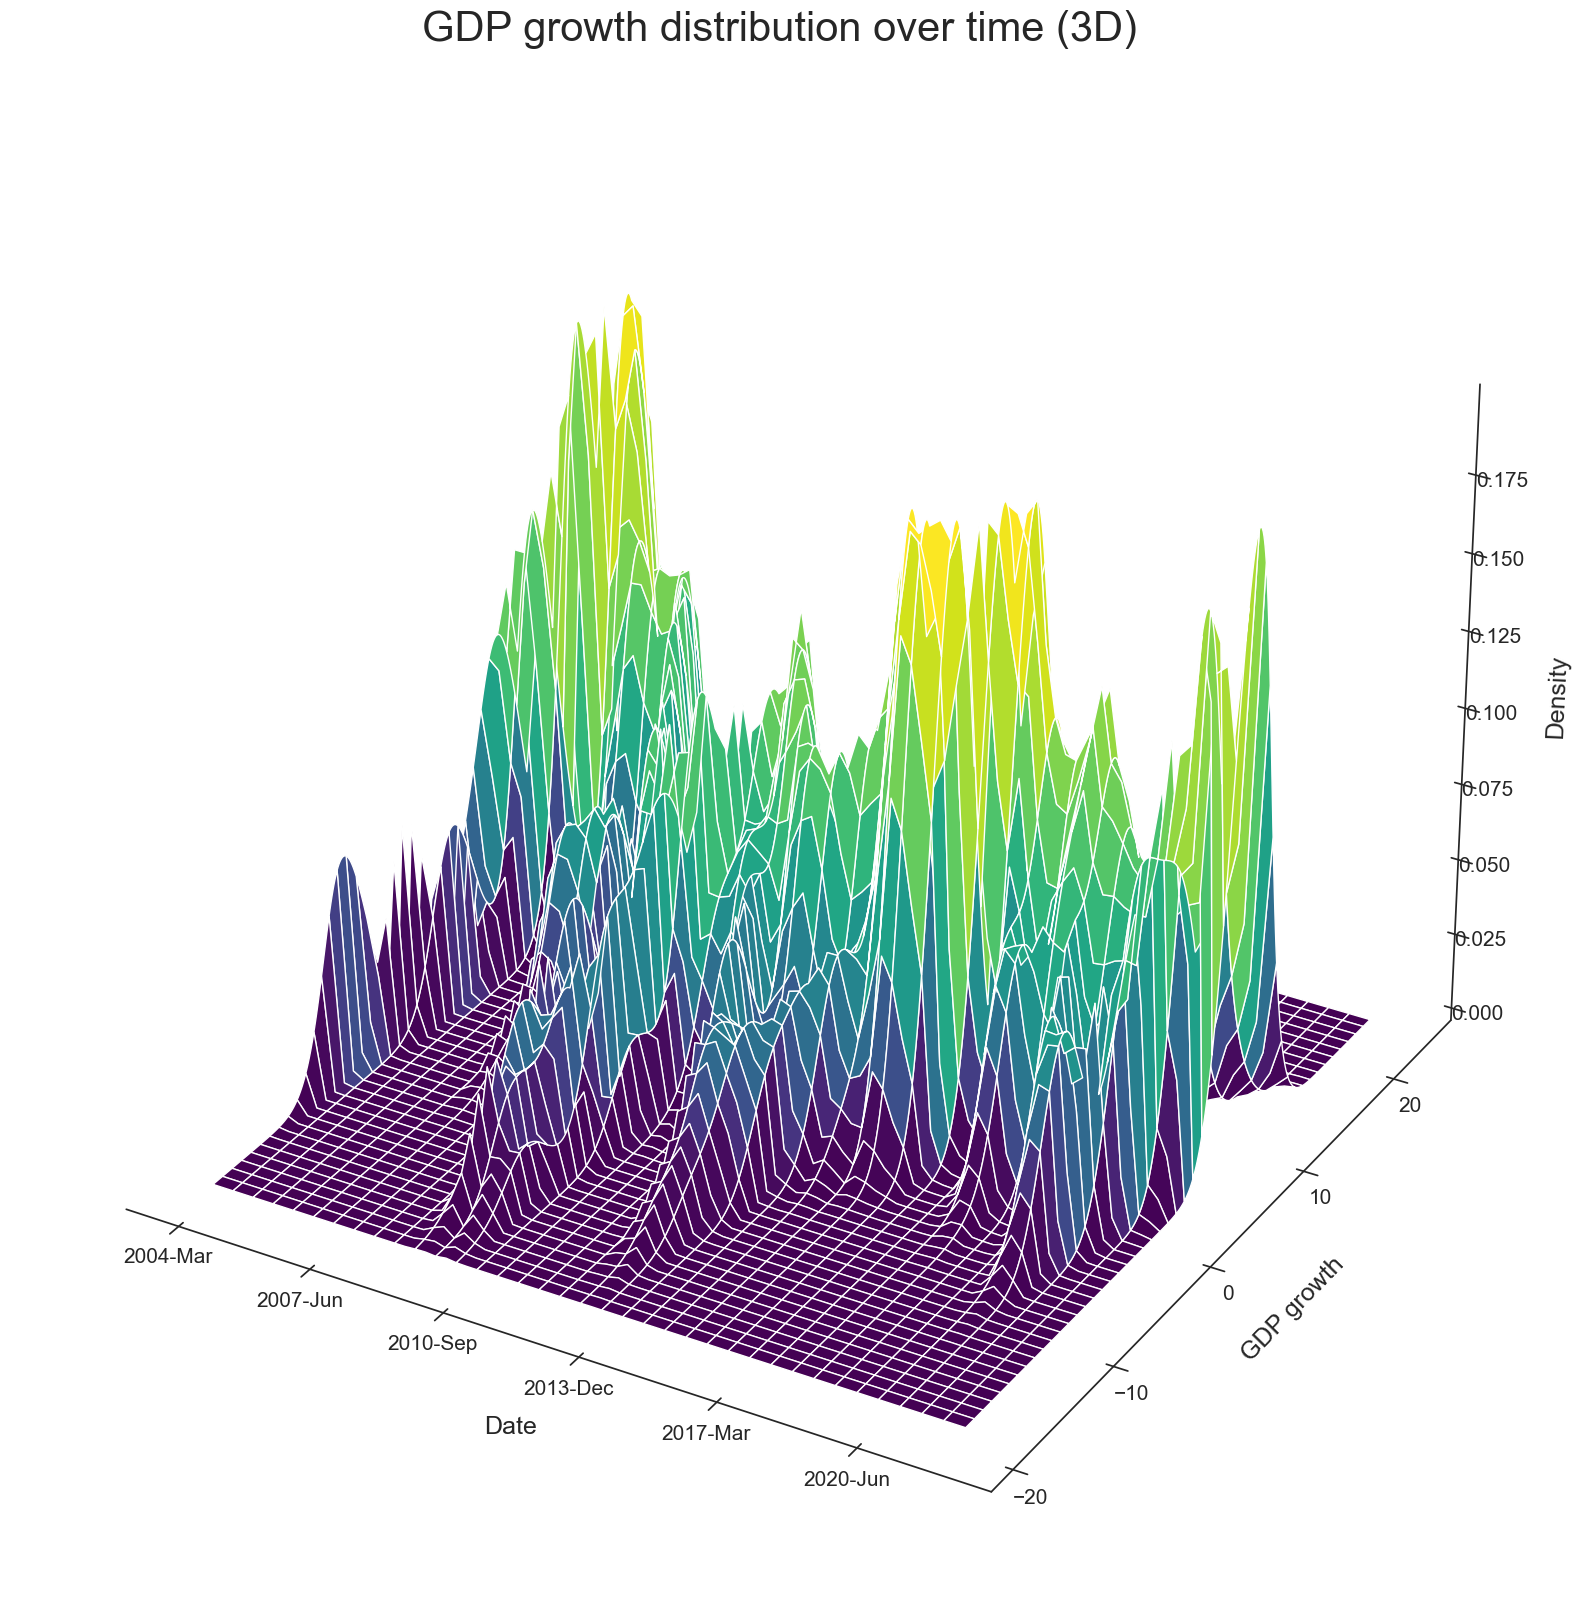

In [76]:
# Data preparation
method = 'Kernel'
gdp_growth = df_PDF_kernel.groupby('date')[method+'_PDF_x'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = df_PDF_kernel.groupby('date')[method+'_PDF_y'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis, 
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'))
ax.set_xlabel('Date', fontsize=18, labelpad=20)
ax.set_ylabel('GDP growth', fontsize=18, labelpad=20)
ax.set_zlabel('Density', fontsize=18, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('GDP growth distribution over time (3D)', fontsize=30)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
# plt.savefig('../Results/GDP_growth_dist_3D.png', bbox_inches='tight', dpi=300)
plt.show()

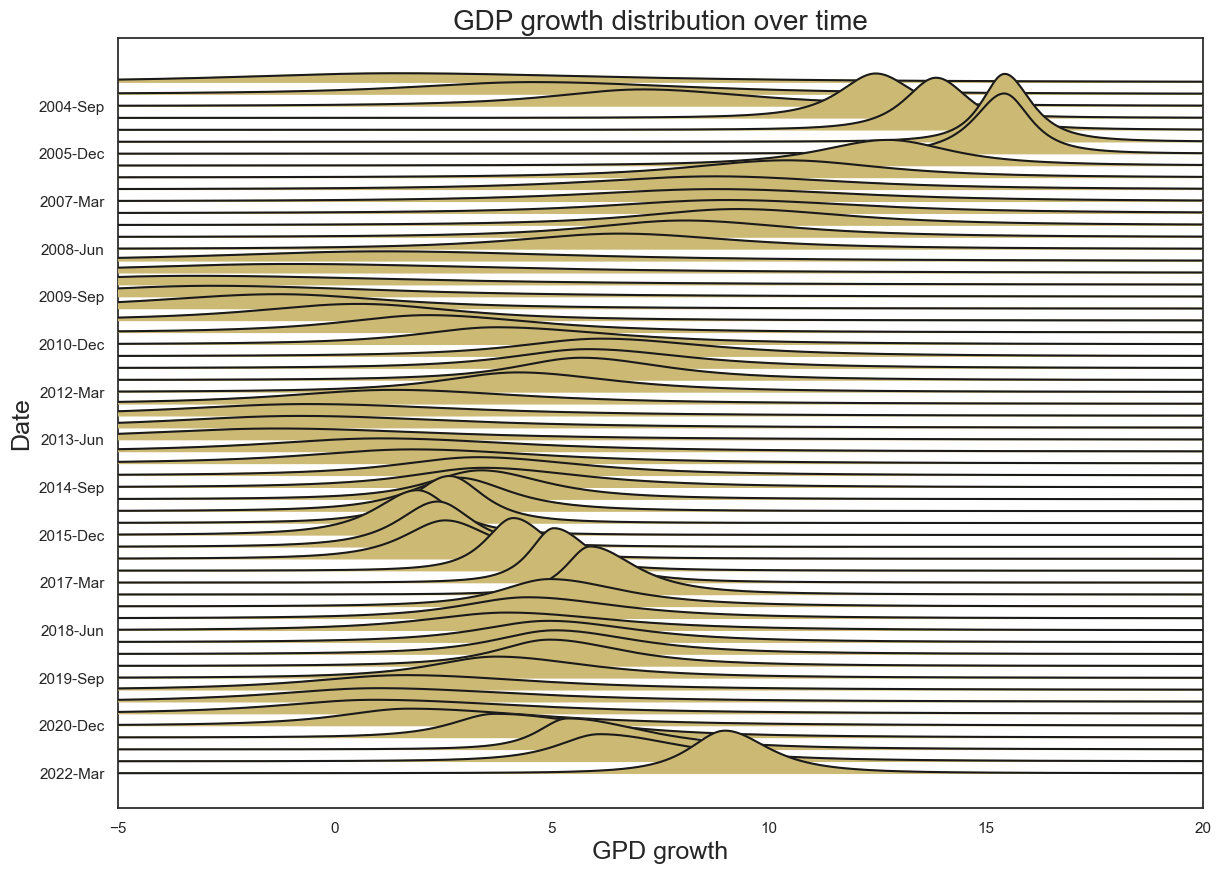

In [64]:
plt.figure(figsize=(14,10))        
plot_data = df_PDF_skew.set_index('date').copy()
ridgeline_custom(plot_data['Tskew_PDF_x'], plot_data['Tskew_PDF_y'], overlap=0.9, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4, 
                 dist_density=5, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.xlim(-5, 20)
# plt.savefig('../Results/GDP_growth_ridge.png', bbox_inches='tight', dpi=300)
plt.show()

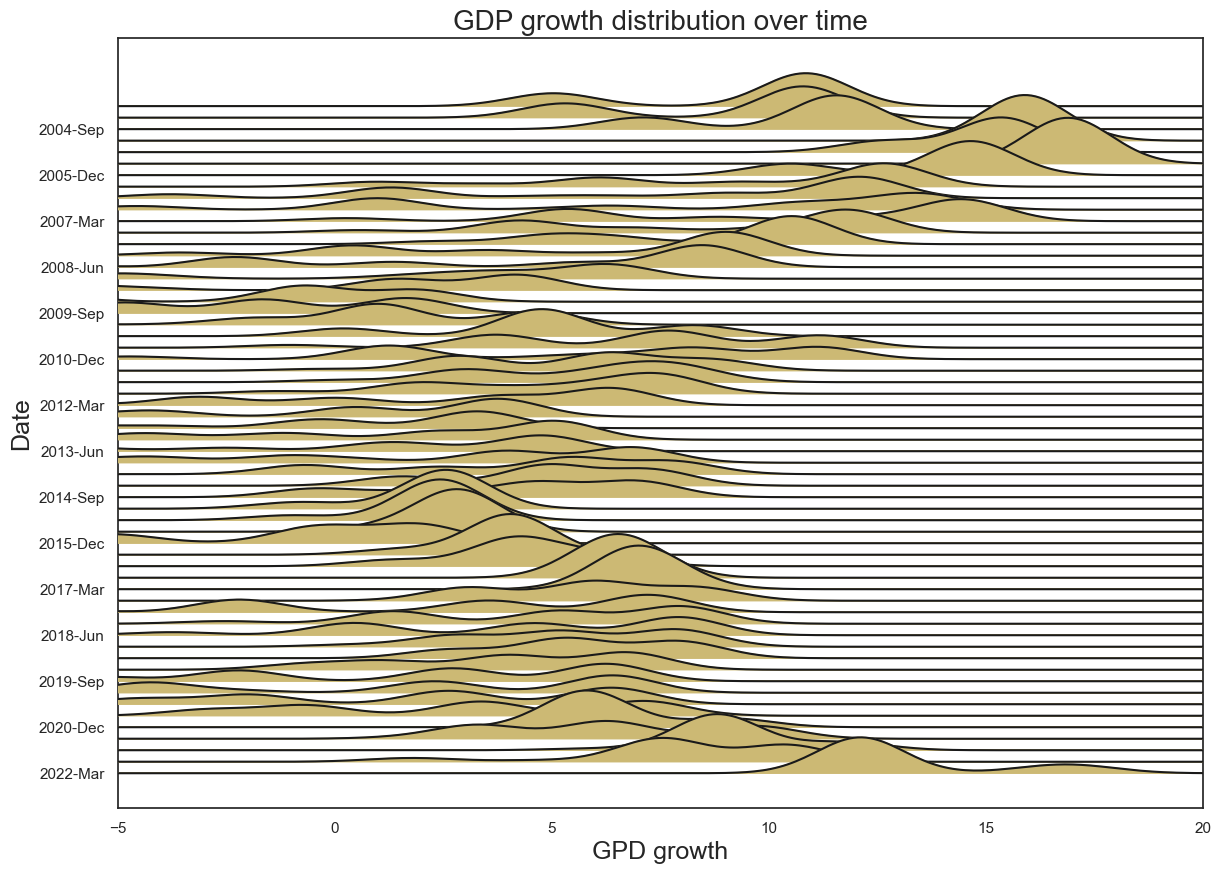

In [67]:
plt.figure(figsize=(14,10))        
plot_data = df_PDF_kernel.set_index('date').copy()
ridgeline_custom(plot_data['Kernel_PDF_x'], plot_data['Kernel_PDF_y'], overlap=0.9, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4, 
                 dist_density=5, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.xlim(-5, 20)
# plt.savefig('../Results/GDP_growth_ridge.png', bbox_inches='tight', dpi=300)
plt.show()

# Experimental

In [128]:
# mode: Free vs Fixed
# mode: Free vs Fixed (always Free for Kernel-based)
# fittype: 'T-skew' vs "Asymmetric T" vs "Kernel-based"
# qsmooth: 'None' vs 'Median' vs 'Mean'
hist_fit_params = {
    'fittype': 'Kernel-based',
    'mode': {'constraint': 'Free', 'value':None, 'bandwidth':1.5},
    'qsmooth': 'None',
    'qsmooth_period': 4,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_historical = {
    'start_date': parser.parse('2003-03-31'),
    'end_date': parser.parse('2022-03-31'),
    'time_inc': 1,
    'fit_params': hist_fit_params,
    **dict_global_params
}
dict_output_historical_kernel = run_historical(dict_input_historical, macro_data, qcoef)

# data setup
hist_sim_kernel_data = dict_output_historical_kernel['data']
df_PDF_kernel = pd.concat(hist_sim_kernel_data['dfpdf'].values, keys=hist_sim_kernel_data['dfpdf'].index).reset_index(level=1, drop=True)
df_PDF_kernel = df_PDF_kernel.reset_index().rename(columns={'index':'date'})

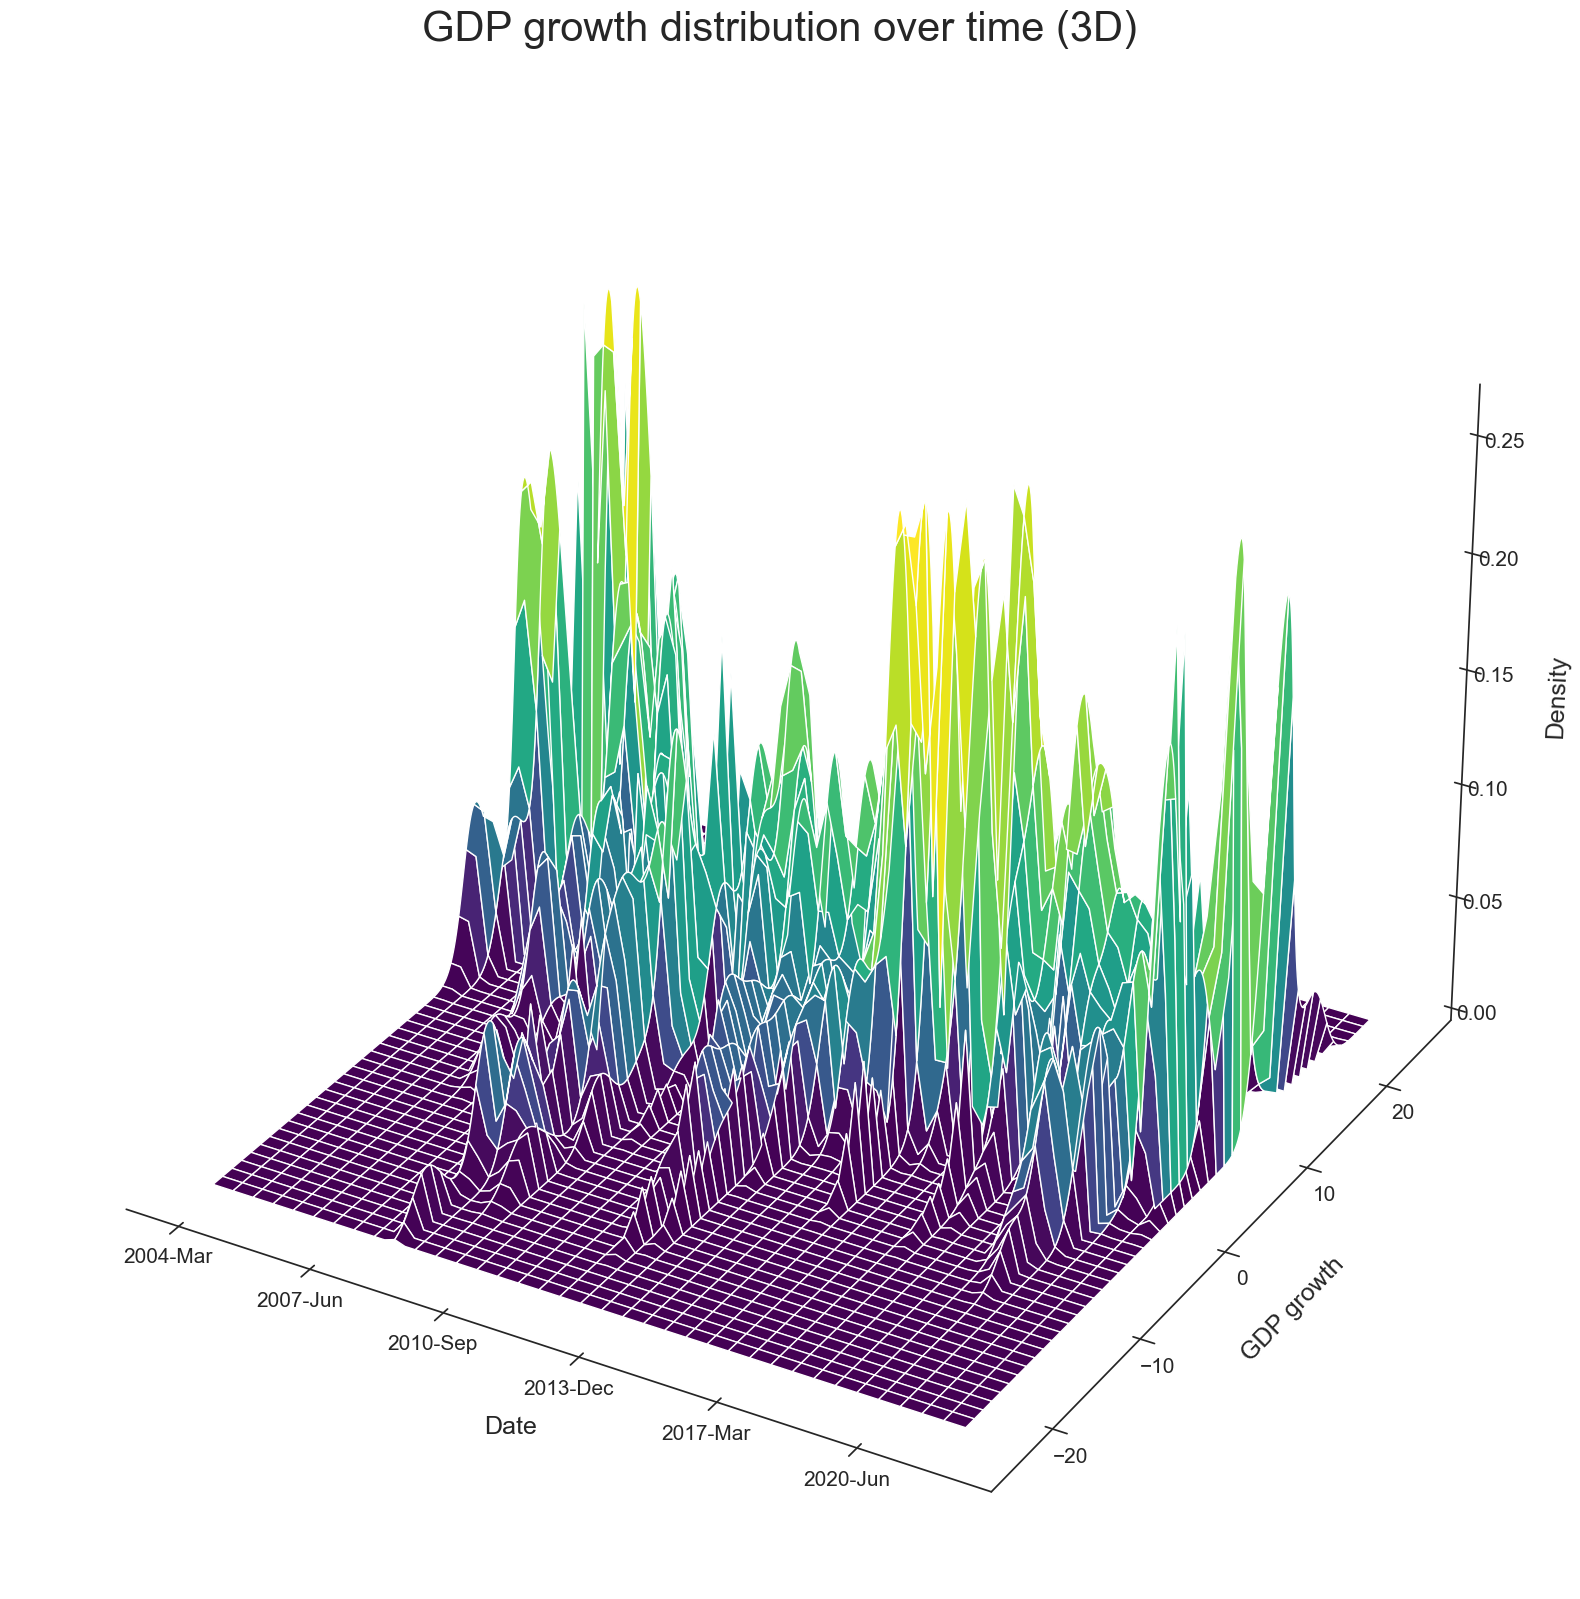

In [129]:
# Data preparation
method = 'Kernel'
gdp_growth = df_PDF_kernel.groupby('date')[method+'_PDF_x'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = df_PDF_kernel.groupby('date')[method+'_PDF_y'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis, 
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'))
ax.set_xlabel('Date', fontsize=18, labelpad=20)
ax.set_ylabel('GDP growth', fontsize=18, labelpad=20)
ax.set_zlabel('Density', fontsize=18, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('GDP growth distribution over time (3D)', fontsize=30)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
# plt.savefig('../Results/GDP_growth_dist_3D.png', bbox_inches='tight', dpi=300)
plt.show()

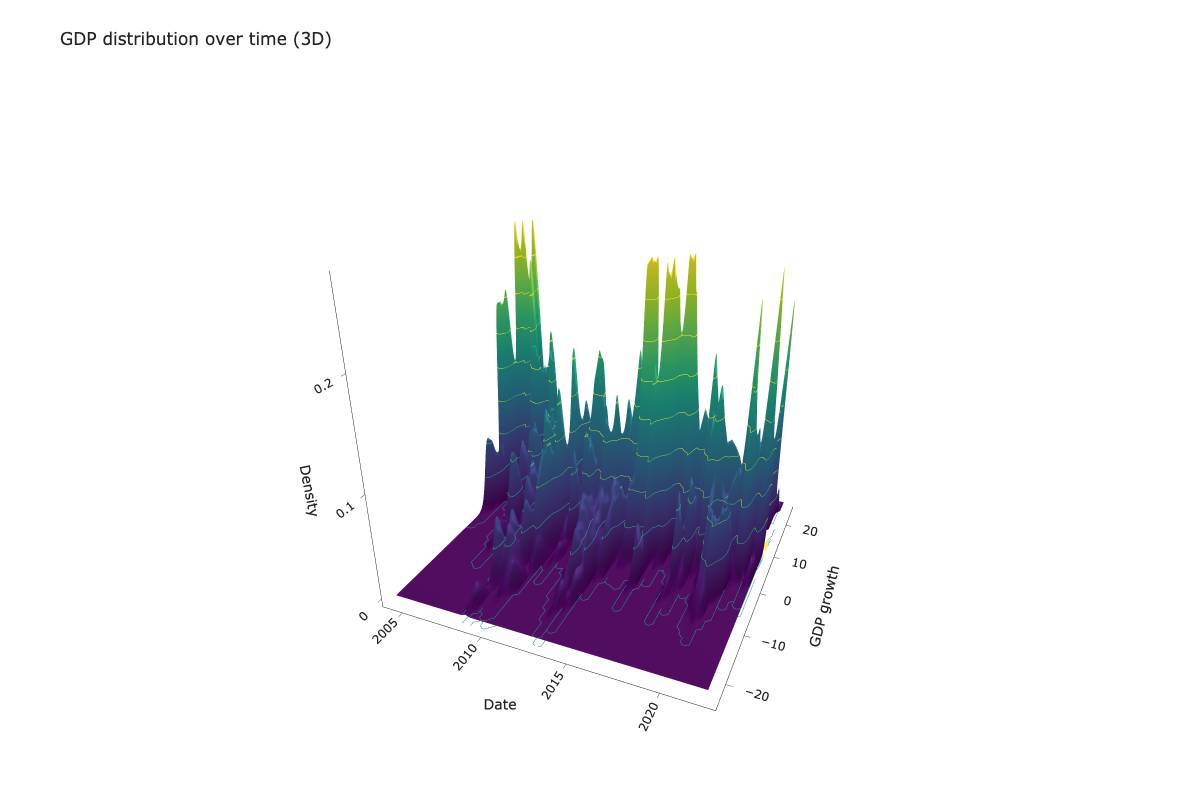

In [130]:
# scaler = prep.Normalizer('l1')
# surf_color = scaler.fit_transform(gdp_density.values.reshape((1, -1))).reshape(gdp_density.values.shape)
surf_color = gdp_density

contours = {
    "z": {"show": True, "start": 0, "end": 1, 
          "size": 1/30, "width": 16, "color": 'white',
          'usecolormap':True, 'highlightcolor':"limegreen",
          'project_z':True
         }
}
surf = go.Surface(x=dates_grid, y=gdp_growth, z=gdp_density,
                  surfacecolor=surf_color, colorscale='Viridis',
                  connectgaps=True, opacity=1, showscale=False,
                  contours=contours)
fig = go.Figure(data=[surf])

fig.update_layout(
    template='simple_white',
    title='GDP distribution over time (3D)',
    autosize=False,
    scene=dict(
        camera_eye=dict(x=0.8, y=-1.9, z=1),
        xaxis_title='Date',
        yaxis_title='GDP growth',
        zaxis_title='Density'
    ),
    width=1200,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
)
fig.write_html('../Results/GDP_kernel_dist_interactive.html')
fig.show(renderer='png', width=1200, height=800)